In [74]:
import pandas as pd

df = pd.read_csv("../data/clean_dataset.csv")


In [75]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [76]:
import numpy as np
from scipy import stats

df.drop(df.columns[0], axis=1, inplace=True)
df.dropna(inplace=True)
df = df[(np.abs(stats.zscore(df["price"])) < 3)]
#q1, q3 = df["price"].quantile([0.25, 0.75])
#iqr = q3 - q1
#df = df[df["price"].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)]

In [77]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [78]:
print(df.describe())
print(df.size)
print(df.ndim)
print(df.size)
print(df.info())

            duration      days_left          price
count  299551.000000  299551.000000  299551.000000
mean       12.218081      26.027494   20741.105508
std         7.195326      13.551117   22475.541804
min         0.830000       1.000000    1105.000000
25%         6.750000      15.000000    4783.000000
50%        11.250000      26.000000    7425.000000
75%        16.170000      38.000000   42457.000000
max        49.830000      49.000000   88950.000000
3295061
2
3295061
<class 'pandas.DataFrame'>
Index: 299551 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           299551 non-null  str    
 1   flight            299551 non-null  str    
 2   source_city       299551 non-null  str    
 3   departure_time    299551 non-null  str    
 4   stops             299551 non-null  str    
 5   arrival_time      299551 non-null  str    
 6   destination_city  299551 non-null  str 

In [79]:
categorial = df[["airline", "source_city", "destination_city", "class", "stops", "arrival_time", "departure_time"]]
nominal = df[["airline", "source_city", "destination_city", "arrival_time", "departure_time"]]
ordinal = df[["class", "stops"]]

quantitative = df[["duration", "days_left", "price"]]
discrete = df[["days_left"]]
continuous = df[["duration", "price"]]

cible = []

print(categorial.head())
print(ordinal.head())
print(quantitative.head())
print(categorial.describe())
print(ordinal.describe())
print(quantitative.describe())


    airline source_city destination_city    class stops   arrival_time  \
0  SpiceJet       Delhi           Mumbai  Economy  zero          Night   
1  SpiceJet       Delhi           Mumbai  Economy  zero        Morning   
2   AirAsia       Delhi           Mumbai  Economy  zero  Early_Morning   
3   Vistara       Delhi           Mumbai  Economy  zero      Afternoon   
4   Vistara       Delhi           Mumbai  Economy  zero        Morning   

  departure_time  
0        Evening  
1  Early_Morning  
2  Early_Morning  
3        Morning  
4        Morning  
     class stops
0  Economy  zero
1  Economy  zero
2  Economy  zero
3  Economy  zero
4  Economy  zero
   duration  days_left  price
0      2.17          1   5953
1      2.33          1   5953
2      2.17          1   5956
3      2.25          1   5955
4      2.33          1   5955
        airline source_city destination_city    class   stops arrival_time  \
count    299551      299551           299551   299551  299551       299551   
uni

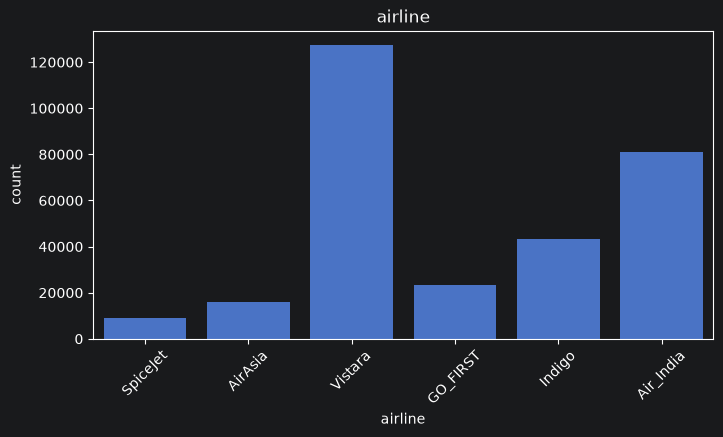

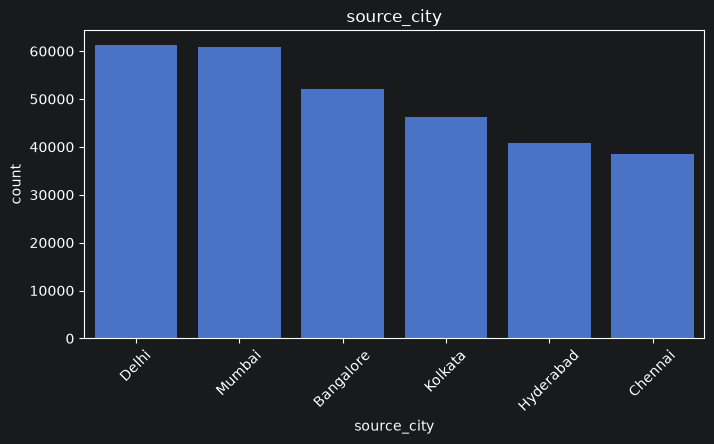

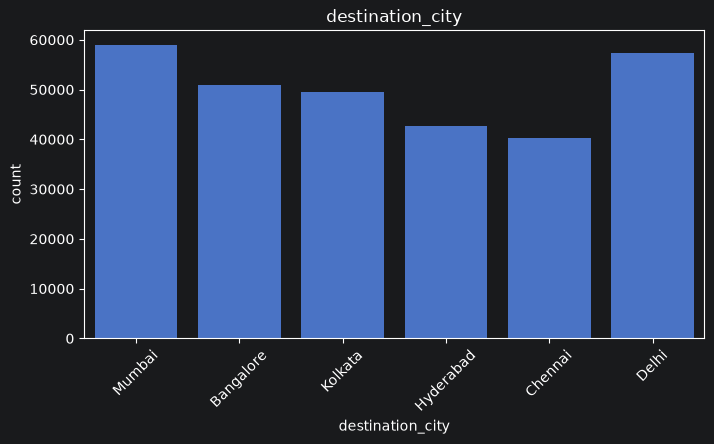

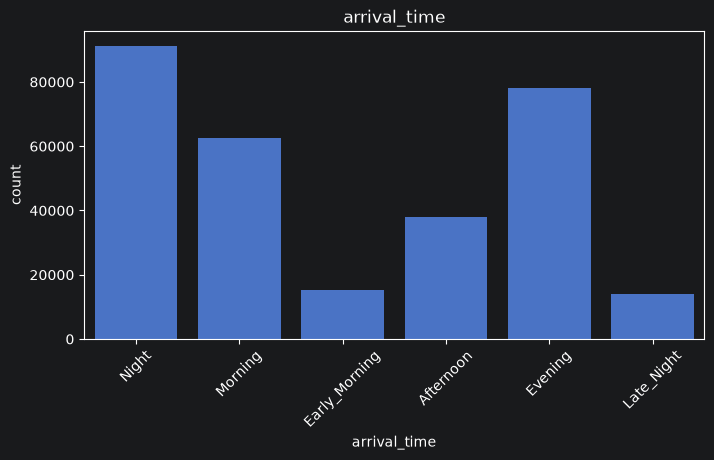

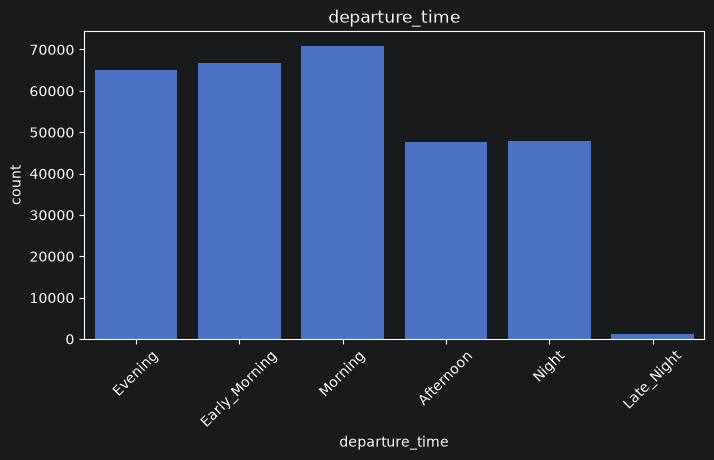

In [80]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


for i in nominal.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=i)
    plt.title(i)
    plt.xticks(rotation=45)
    plt.show()



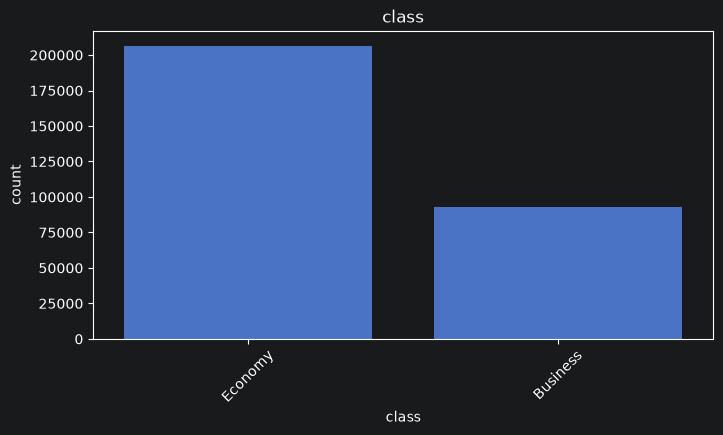

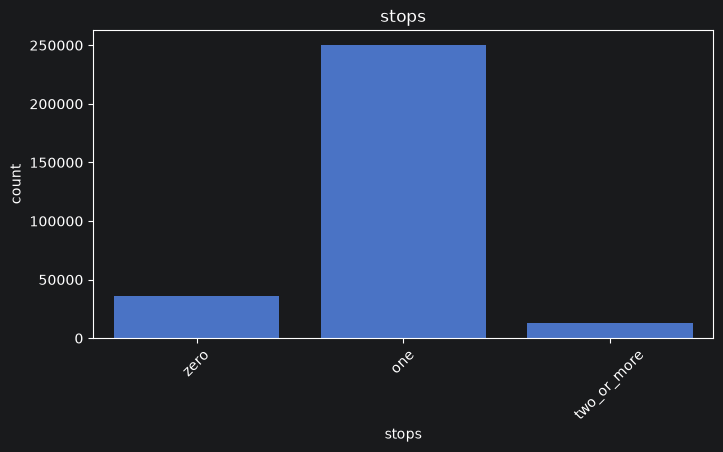

In [81]:
for i in ordinal.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=i)
    plt.title(i)
    plt.xticks(rotation=45)
    plt.show()


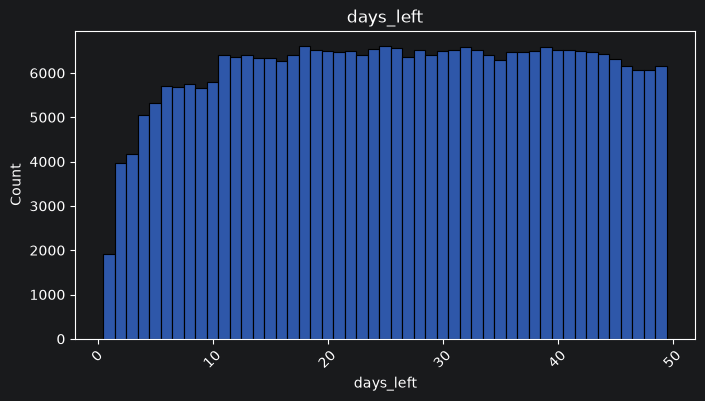

In [82]:
plt.figure(figsize=(8, 4))
sns.histplot(discrete=True,data=df, x="days_left")
plt.title("days_left")
plt.xticks(rotation=45)
plt.show()

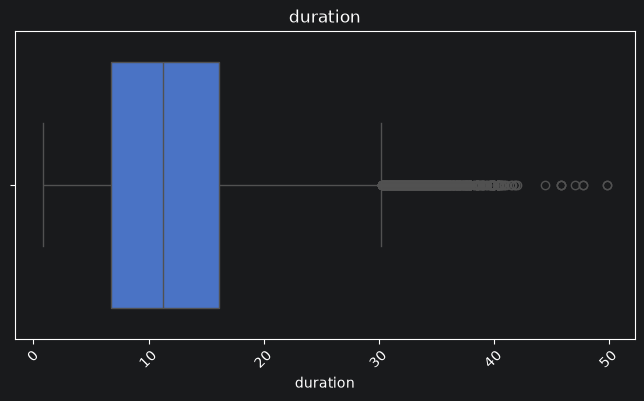

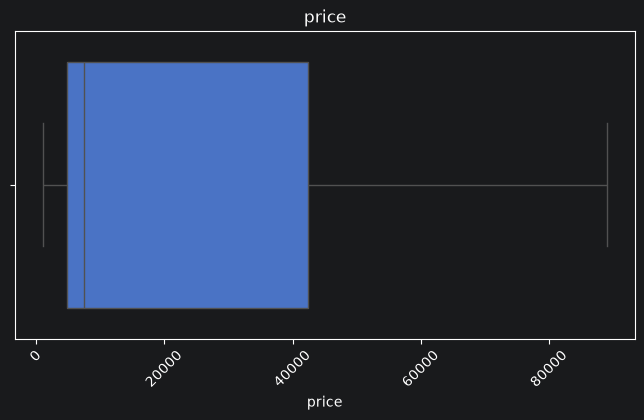

In [83]:
for i in continuous.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=i)
    plt.title(i)
    plt.xticks(rotation=45)
    plt.show()

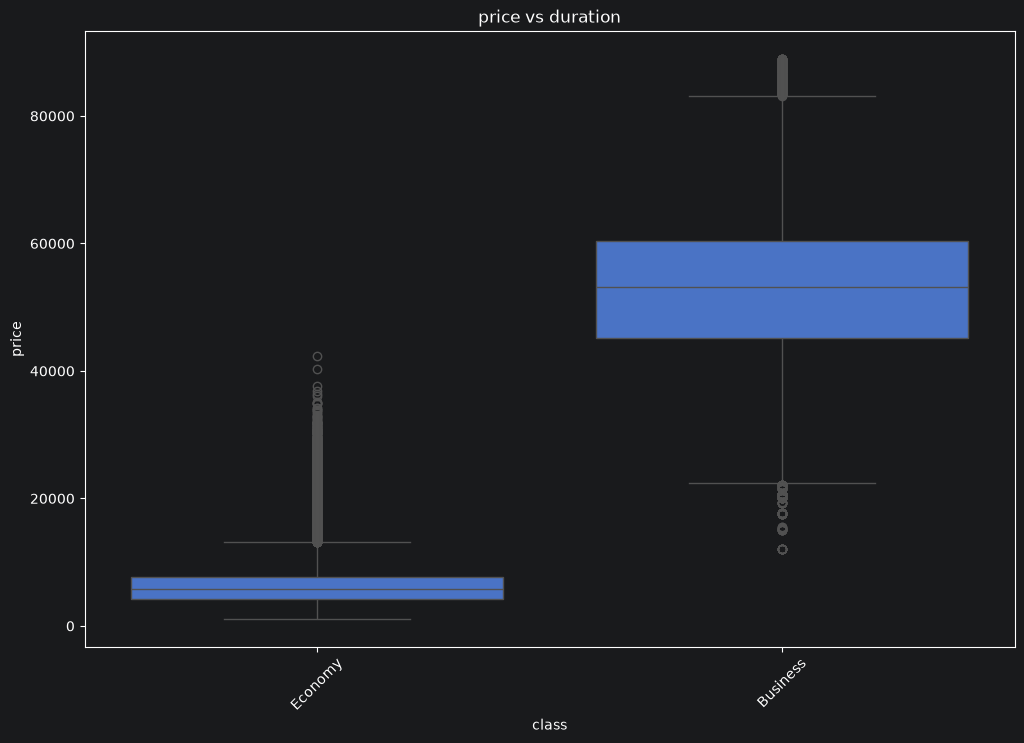

In [84]:
plt.figure(figsize=(12, 8))
sns.boxplot(y=continuous["price"], x=ordinal["class"])
plt.title("price vs duration")
plt.xticks(rotation=45)
plt.show()

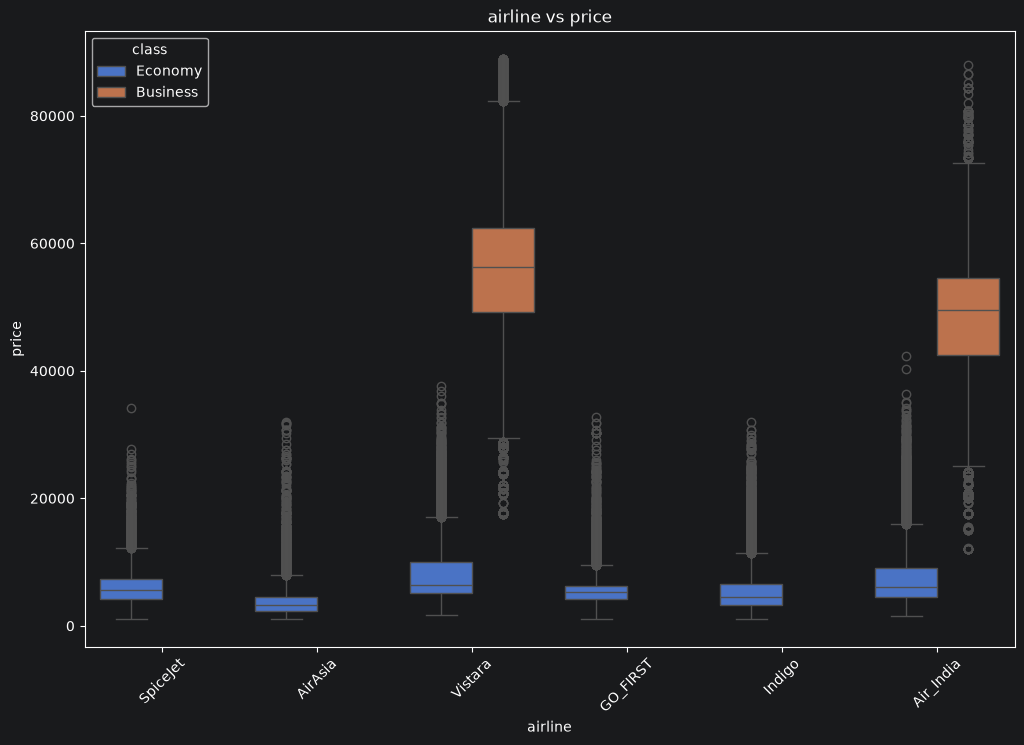

In [85]:
plt.figure(figsize=(12, 8))
sns.boxplot(y=continuous["price"], x=nominal["airline"], hue=ordinal["class"])
plt.title("airline vs price")
plt.xticks(rotation=45)
plt.show()


# Class and airline's influence on the price

from the two above graphs we can observe that the airline itself, has a hand on how hight the price for the ticket is, although not as much as the class, we can observe that the class has a much larger influence on the ticket price.

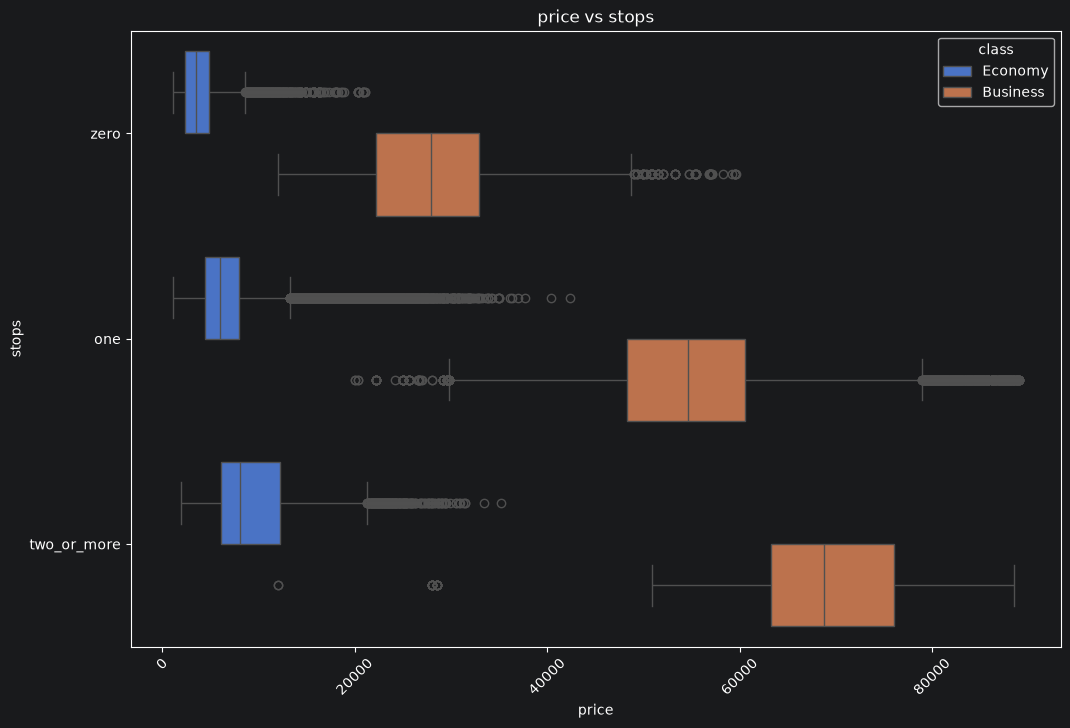

In [86]:
plt.figure(figsize=(12, 8))
sns.boxplot(x=continuous["price"], y=ordinal["stops"], hue=ordinal["class"])
plt.title("price vs stops")
plt.xticks(rotation=45)
plt.show()


# Stops & class influence on the price
the more stops there are the higher the median ticket price is, although some outliers, most trips respect this rule.
Again like the previous observation of airline & class with prices, class here has a very high influence in the price

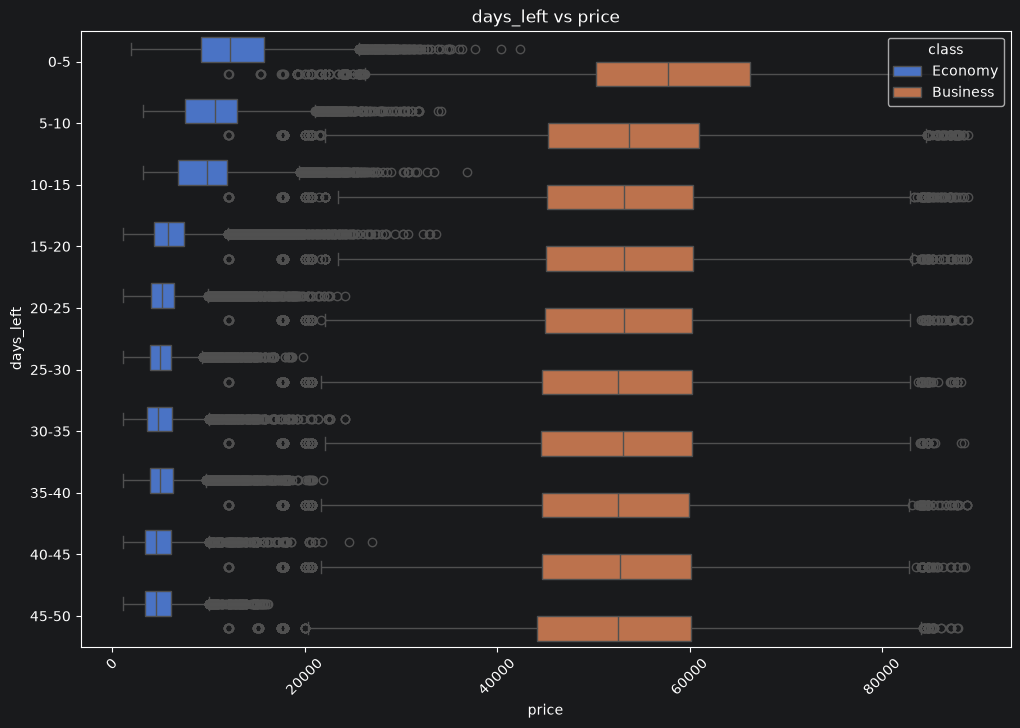

In [87]:
bins = list(range(0, discrete["days_left"].max() + 5, 5))
labels = [f"{b}-{b+5}" for b in bins[:-1]]
days_binned = pd.cut(discrete["days_left"], bins=bins, labels=labels, right=False)

plt.figure(figsize=(12, 8))
sns.boxplot(x=continuous["price"], y=days_binned, hue=ordinal["class"])
plt.title("days_left vs price")
plt.xticks(rotation=45)
plt.show()

# Days_left & price
The closer the trip iss the higher the median price is

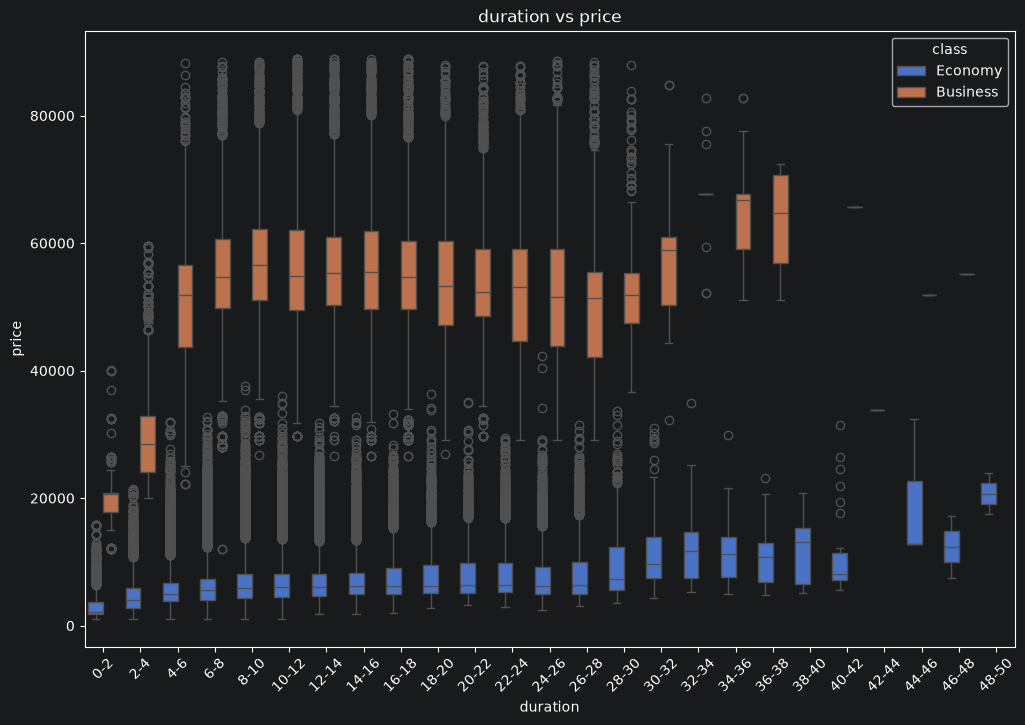

In [88]:
import math

bins = list(range(0, math.ceil(continuous["duration"].max()) + 2, 2))
labels = [f"{b}-{b+2}" for b in bins[:-1]]
duration_binned = pd.cut(continuous["duration"], bins=bins, labels=labels, right=False)
plt.figure(figsize=(12, 8))
sns.boxplot(x=duration_binned, y=continuous["price"], hue=ordinal["class"])
plt.title("duration vs price")
plt.xticks(rotation=45)
plt.show()

# Trip duration's influence on the price
We can see a drastic spike in the price from 0-2 to 2-4 to 4-6 in the buiseness class, after that it semi stabalizes, and then rises steadelly in the 28-30 mark.

On the contrary, the econamy class has no drastic spikes, but rises steadely the higher the flight duration gets

In [89]:

nominal_encoded = pd.get_dummies(nominal)

In [90]:
def flatten_extend(matrix):
    flat_list = []
    for row in matrix:
        flat_list.extend(row)
    return flat_list


In [91]:
ordinal["class"].unique()

<StringArray>
['Economy', 'Business']
Length: 2, dtype: str

In [92]:
from sklearn.preprocessing import OrdinalEncoder
columns = list(ordinal.columns.values)
ordinal = ordinal[["class", "stops"]]
encoder = OrdinalEncoder(categories=[["Economy", "Business"], ["zero", "one", "two_or_more"]])
ordinal_encoded_array = encoder.fit_transform(ordinal)

In [93]:
ordinal_encoded_array

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [1., 1.],
       [1., 1.],
       [1., 1.]], shape=(299551, 2))

In [94]:
normalized_quant = (quantitative - quantitative.min()) / (quantitative.max() - quantitative.min())

In [95]:
ordinal_encoded = pd.DataFrame(ordinal_encoded_array)
encoded_data = pd.concat([nominal_encoded, ordinal_encoded, normalized_quant], axis=1)
encoded_data.dropna(inplace=True)
encoded_data.columns = encoded_data.columns.astype(str)

In [96]:
encoded_data

,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Bangalore,source_city_Chennai,source_city_Delhi,source_city_Hyderabad,...,departure_time_Early_Morning,departure_time_Evening,departure_time_Late_Night,departure_time_Morning,departure_time_Night,0,1,duration,days_left,price
0,False,False,False,False,True,False,False,False,True,False,...,False,True,False,False,False,0.0,0.0,0.027347,0.000000,0.055188
1,False,False,False,False,True,False,False,False,True,False,...,True,False,False,False,False,0.0,0.0,0.030612,0.000000,0.055188
2,True,False,False,False,False,False,False,False,True,False,...,True,False,False,False,False,0.0,0.0,0.027347,0.000000,0.055222
3,False,False,False,False,False,True,False,False,True,False,...,False,False,False,True,False,0.0,0.0,0.028980,0.000000,0.055211
4,False,False,False,False,False,True,False,False,True,False,...,False,False,False,True,False,0.0,0.0,0.030612,0.000000,0.055211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299546,False,True,False,False,False,False,False,True,False,False,...,False,False,False,False,True,1.0,1.0,0.452449,0.729167,0.571916
299547,False,True,False,False,False,False,False,True,False,False,...,False,True,False,False,False,1.0,1.0,0.117347,0.729167,0.709614
299548,False,True,False,False,False,False,False,True,False,False,...,False,True,False,False,False,1.0,1.0,0.340204,0.729167,0.709614
299549,False,False,False,False,False,True,False,True,False,False,...,False,False,False,True,False,1.0,1.0,0.190612,0.729167,0.747612


# Machin training:

In [97]:
from sklearn.model_selection import train_test_split

x = encoded_data.drop("price", axis=1)
y = encoded_data["price"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x.columns)

Index(['airline_AirAsia', 'airline_Air_India', 'airline_GO_FIRST',
       'airline_Indigo', 'airline_SpiceJet', 'airline_Vistara',
       'source_city_Bangalore', 'source_city_Chennai', 'source_city_Delhi',
       'source_city_Hyderabad', 'source_city_Kolkata', 'source_city_Mumbai',
       'destination_city_Bangalore', 'destination_city_Chennai',
       'destination_city_Delhi', 'destination_city_Hyderabad',
       'destination_city_Kolkata', 'destination_city_Mumbai',
       'arrival_time_Afternoon', 'arrival_time_Early_Morning',
       'arrival_time_Evening', 'arrival_time_Late_Night',
       'arrival_time_Morning', 'arrival_time_Night',
       'departure_time_Afternoon', 'departure_time_Early_Morning',
       'departure_time_Evening', 'departure_time_Late_Night',
       'departure_time_Morning', 'departure_time_Night', '0', '1', 'duration',
       'days_left'],
      dtype='str')


# Models:

In [98]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor()
dummy.fit(x_train, y_train)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None
Name,Type,Value
"constant_ constant_: ndarray of shape (1, n_outputs)Mean or median or quantile of the training targets or constant valuegiven by the user.","ndarray[float64](1, 1)",[[0.22]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](34,)","['airline_AirAsia','airline_Air_India','airline_GO_FIRST',...,'1', 'duration','days_left']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,34
n_outputs_ n_outputs_: intNumber of outputs.,int,1


In [99]:
from sklearn.linear_model import LinearRegression

Linear = LinearRegression()
Linear.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](34,)","[-0.01,-0.02, 0.01,..., 0.01, 0.13,-0.07]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](34,)","['airline_AirAsia','airline_Air_India','airline_GO_FIRST',...,'1', 'duration','days_left']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.05655
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(29)


In [100]:
from sklearn.linear_model import RidgeCV
RidgeCV = RidgeCV(alphas=[0.01, 0.05, 0.1, 0.5, 1.0], cv=5)
RidgeCV.fit(x_train, y_train)
print(RidgeCV.alpha_)

1.0


In [101]:
from sklearn.ensemble import RandomForestRegressor
Forest = RandomForestRegressor(n_estimators=50, random_state=42)
Forest.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [102]:
# from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
#
# def test_model(model, x_test, y_test):
#     pred = model.predict(x_test)
#     #print(f"R²: {model.score(x_test, y_test):.4f}\n")
#
#     print("### Scors ###\n")
#     print(f"R2: {r2_score(y_test, pred)}")
#     print(f"MAE: {mean_squared_error(y_test, pred)}")
#     print(f"RMSE: {root_mean_squared_error(y_test, pred)}")
#
#     print("\n\n### Graphs ###")
#     comparison = pd.DataFrame({
#         "real_price": y_test.values,
#         "predicted_price": pred,
#         "class": x_test["0"].values,
#     })
#     comparison["residual"] = comparison["real_price"] - comparison["predicted_price"]
#
#     plt.figure(figsize=(8, 8))
#     sns.scatterplot(data=comparison, x="real_price", y="predicted_price",
#                     hue="class", alpha=0.5)
#     lims = [comparison[["real_price", "predicted_price"]].min().min(),
#             comparison[["real_price", "predicted_price"]].max().max()]
#     plt.plot(lims, lims, color="red", linestyle="--")
#     plt.xlabel("Real price")
#     plt.ylabel("Predicted price")
#     plt.title("Real vs predicted")
#     plt.show()
#
#     plt.figure(figsize=(10, 6))
#     sns.scatterplot(data=comparison, x="predicted_price", y="residual",
#                     hue="class", alpha=0.5)
#     plt.axhline(0, color="red", linestyle="--")
#     plt.title("Residuals")
#     plt.show()
#     print("\n\n\n\n")
#     return comparison

In [103]:
# from sklearn.model_selection import cross_val_score, KFold
# from sklearn.svm import SVC
#
# def k_fold(model):
#     num_folds = 5
#     kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
#     cross_val_results = cross_val_score(model, x_train, y_train, cv=kf)
#     print("\n\nCross-Validation Results (Accuracy):")
#     for i, result in enumerate(cross_val_results, 1):
#         print(f"  Fold {i}: {result * 100:.2f}%")
#
#     print(f'Mean Accuracy: {cross_val_results.mean()* 100:.2f}%')

In [104]:
# models = [dummy, Linear, RidgeCV, Forest]
# for model in models:
#     print(f"Testing {model}")
#     test_model(model, x_test, y_test)
#     k_fold(model)
#     print("\n\n\n")

 # -----------------

In [105]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)
from sklearn.model_selection import cross_val_score, KFold


In [106]:
def plot_model(name, model, x_test, y_test):
    pred = model.predict(x_test)

    comparison = pd.DataFrame({
        "real_price": y_test.values,
        "predicted_price": pred,
        "class": x_test["0"].values,
    })
    comparison["residual"] = comparison["real_price"] - comparison["predicted_price"]

    # Real vs predicted
    plt.figure(figsize=(8, 8))
    sns.scatterplot(data=comparison, x="real_price", y="predicted_price",
                    hue="class", alpha=0.5)
    lims = [comparison[["real_price", "predicted_price"]].min().min(),
            comparison[["real_price", "predicted_price"]].max().max()]
    plt.plot(lims, lims, color="red", linestyle="--")
    plt.xlabel("Real price")
    plt.ylabel("Predicted price")
    plt.title(f"{name}: Real vs predicted")
    plt.show()

    # Residuals
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=comparison, x="predicted_price", y="residual",
                    hue="class", alpha=0.5)
    plt.axhline(0, color="red", linestyle="--")
    plt.title(f"{name}: Residuals")
    plt.show()

    return comparison


In [107]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(name, model):
    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    # Cross-validation on the training set (R2, since these are regressors)
    cv = cross_val_score(model, x_train, y_train, cv=kf, scoring="r2")

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    return {
        "model": name,
        # Results
        "test_R2": test_r2,
        "test_MAE": mean_absolute_error(y_test, test_pred),
        "test_RMSE": root_mean_squared_error(y_test, test_pred),
        # Stability
        "cv_R2_mean": cv.mean(),
        "cv_R2_std": cv.std(),
        # Generalization
        "train_R2": train_r2,
        "gap_train_test": train_r2 - test_r2,
    }


Evaluating Dummy


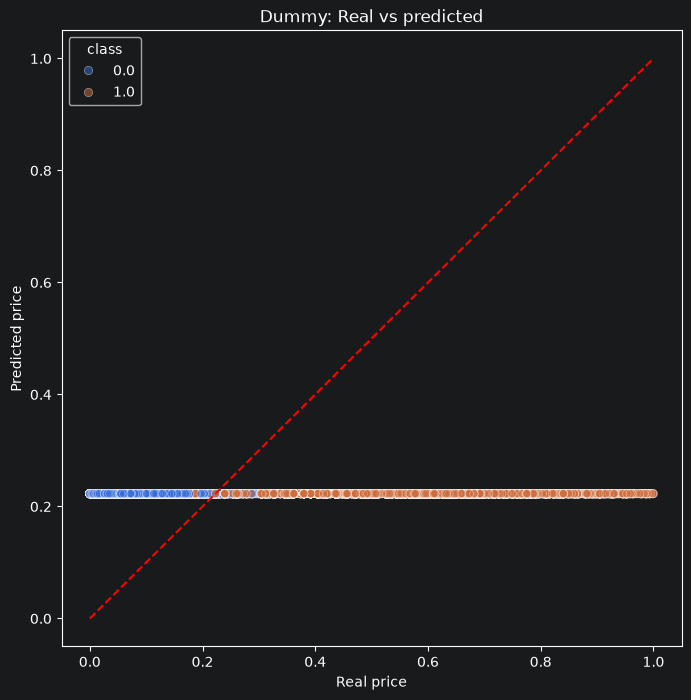

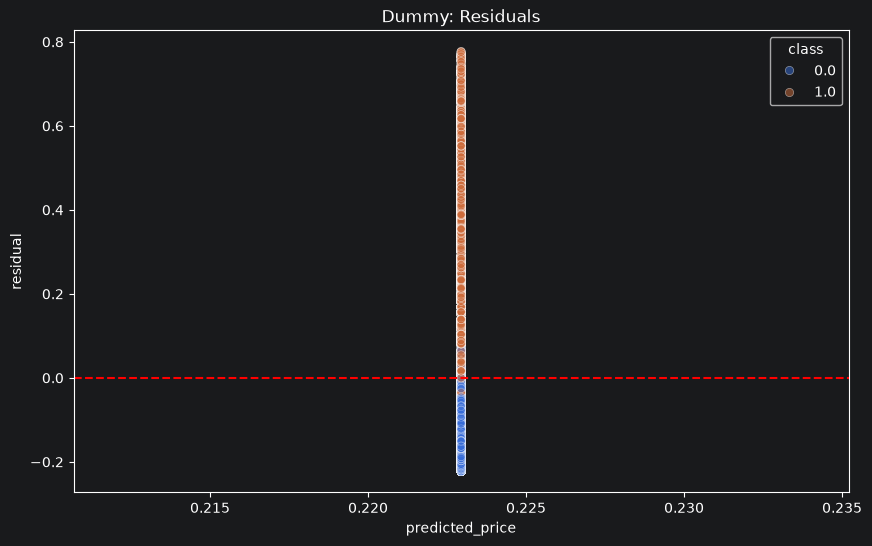

Evaluating Linear


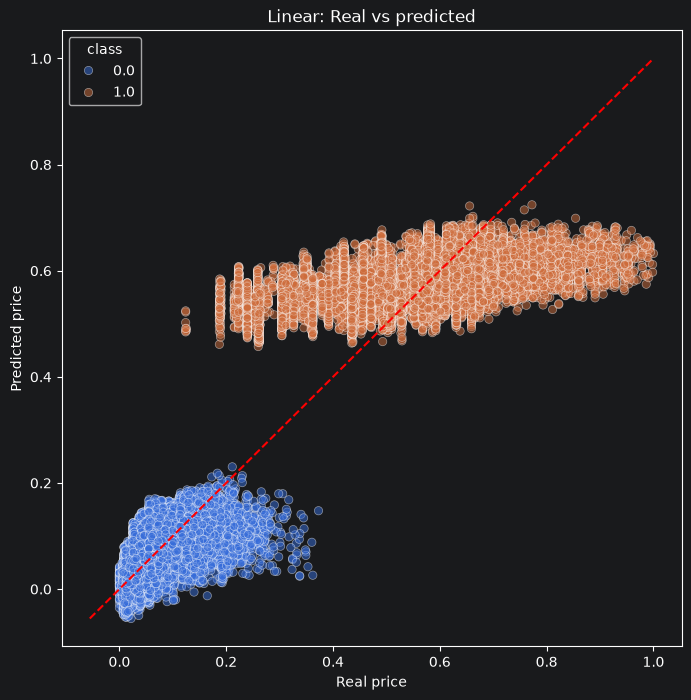

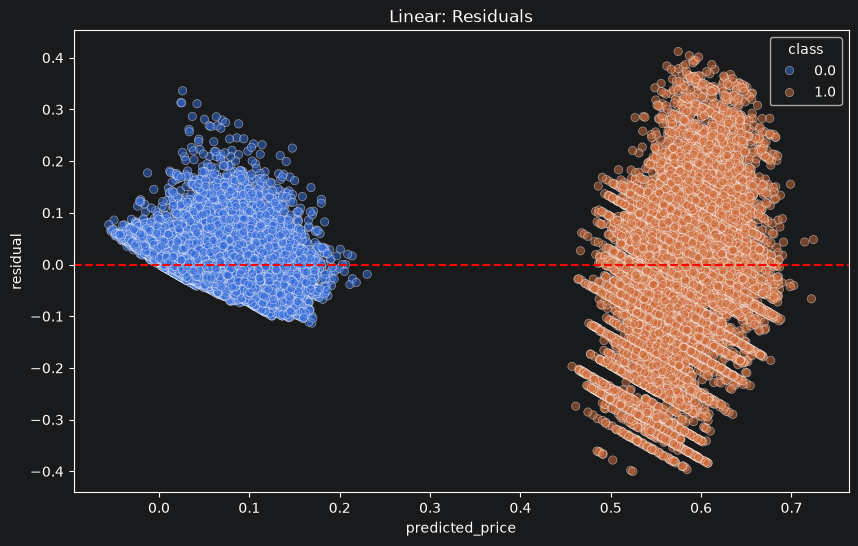

Evaluating RidgeCV


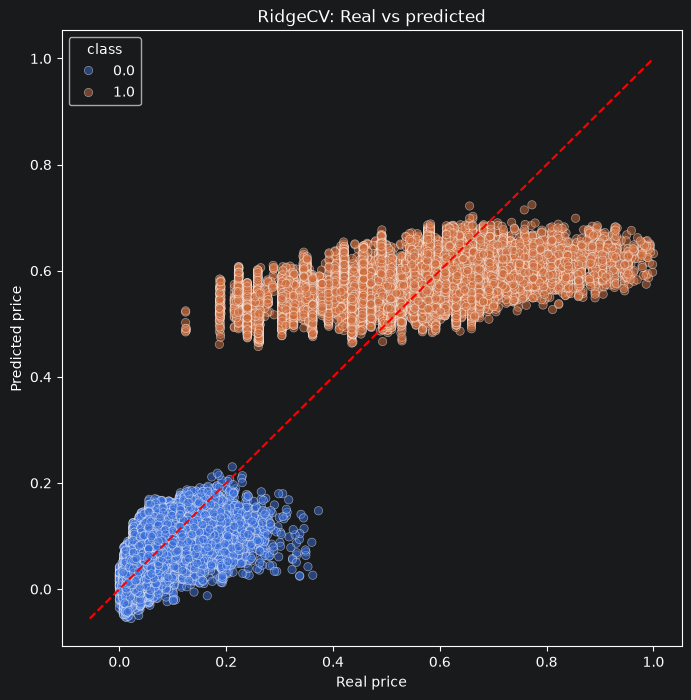

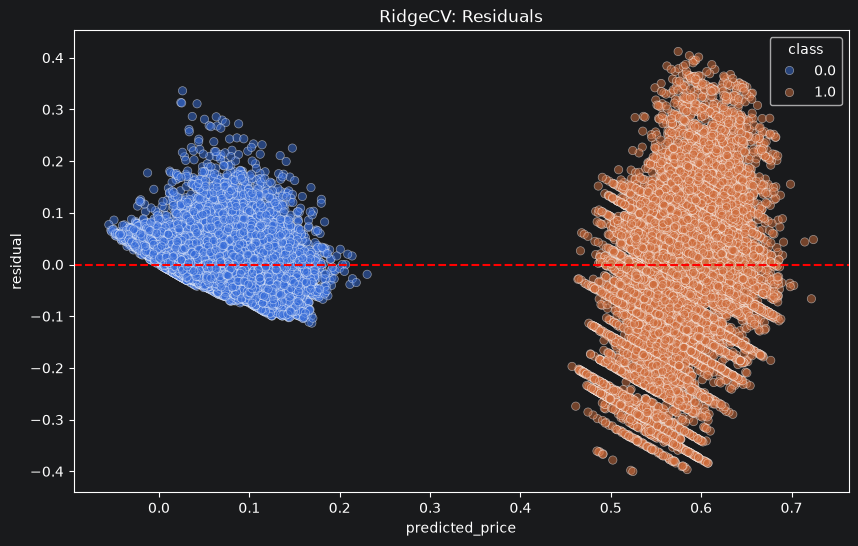

Evaluating Forest


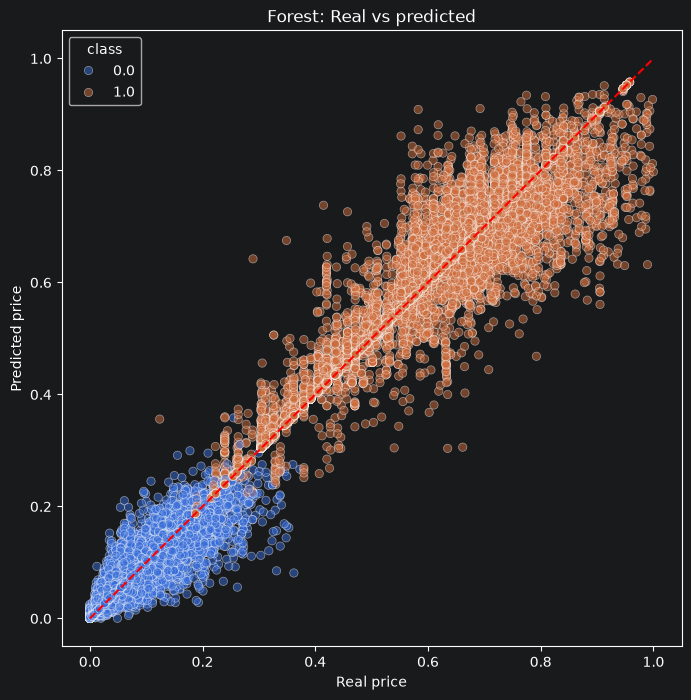

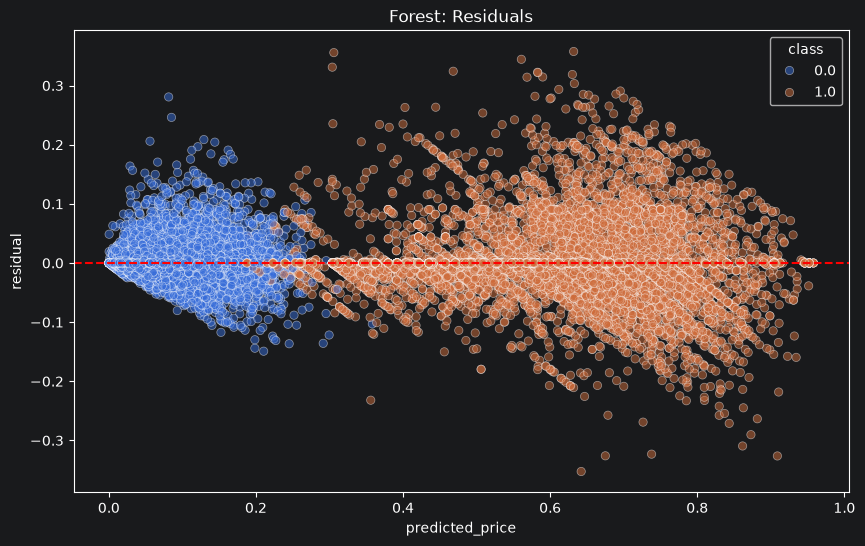

In [108]:
models = {
    "Dummy": dummy,
    "Linear": Linear,
    "RidgeCV": RidgeCV,
    "Forest": Forest,
}

SHOW_PLOTS = True

rows = []
for name, model in models.items():
    print(f"Evaluating {name}")
    rows.append(evaluate(name, model))
    if SHOW_PLOTS:
        plot_model(name, model, x_test, y_test)

results = pd.DataFrame(rows).set_index("model")


In [112]:
results.columns = pd.MultiIndex.from_tuples([
    ("Results", "test_R2"),
    ("Results", "test_MAE"),
    ("Results", "test_RMSE"),
    ("Stability", "cv_R2_mean"),
    ("Stability", "cv_R2_std"),
    ("Generalization", "train_R2"),
    ("Generalization", "gap_train_test"),
])

summary = results.sort_values(("Results", "test_R2"), ascending=False).round(4)
summary


Results                     Stability           Generalization  \
        test_R2 test_MAE test_RMSE cv_R2_mean cv_R2_std       train_R2   
model                                                                    
Forest   0.9872   0.0114    0.0289     0.9867    0.0003         0.9978   
Linear   0.9068   0.0498    0.0779     0.9073    0.0010         0.9074   
RidgeCV  0.9068   0.0498    0.0779     0.9073    0.0010         0.9074   
Dummy   -0.0000   0.2224    0.2553    -0.0000    0.0000         0.0000   

                        
        gap_train_test  
model                   
Forest          0.0106  
Linear          0.0006  
RidgeCV         0.0006  
Dummy           0.0000

In [110]:
higher_better = [("Results", "test_R2"), ("Stability", "cv_R2_mean"),
                 ("Generalization", "train_R2")]
lower_better = [("Results", "test_MAE"), ("Results", "test_RMSE"),
                ("Stability", "cv_R2_std"), ("Generalization", "gap_train_test")]

(summary.style
    .highlight_max(subset=higher_better, color="#0015FF")
    .highlight_min(subset=lower_better, color="#5500FF")
    .format("{:.4f}"))


In [116]:
best = results[("Stability","cv_R2_mean")].idxmax()   # or pick by hand if the std/gap changes your mind
print("Selected model:", best)
results.loc[best]

Selected model: Forest


Results         test_R2           0.987203
                test_MAE          0.011431
                test_RMSE         0.028885
Stability       cv_R2_mean        0.986711
                cv_R2_std         0.000253
Generalization  train_R2          0.997761
                gap_train_test    0.010558
Name: Forest, dtype: float64

In [120]:

y.median()

np.float64(0.07193351926689055)